In [1]:
# ============================================================
# CELDA 2
# Conectar Google Drive
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Conectamos Colab con Google Drive
# ------------------------------------------------------------

from google.colab import drive

drive.mount("/content/drive")

print("=" * 70)
print("GOOGLE DRIVE CONECTADO")
print("=" * 70)


Mounted at /content/drive
GOOGLE DRIVE CONECTADO


In [2]:
# ============================================================
# CELDA 3
# Importar librerías
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Importamos las librerías necesarias para HDF5, procesamiento de señales, gráficos, TensorFlow/Keras y métricas.
# ------------------------------------------------------------

import os
import gc
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt

from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

print("=" * 70)
print("ENTORNO PREPARADO")
print("=" * 70)
print(f"TensorFlow: {tf.__version__}")


ENTORNO PREPARADO
TensorFlow: 2.20.0


In [3]:
# ============================================================
# CELDA 4
# Configurar rutas de datos y carpeta de entrenamiento
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Los datos de entrada se leen exclusivamente desde la carpeta
# "agent1-ecg" de Google Drive.
#
# Todos los archivos generados por este notebook se guardarán
# dentro de la carpeta "entrenamiento" q se crea al ejecutar esta celda en Google Drive.
# ------------------------------------------------------------

CARPETA_DATOS = "/content/drive/MyDrive/agent1-ecg"
CARPETA_ENTRENAMIENTO = "/content/drive/MyDrive/entrenamiento"

# ------------------------------------------------------------
# Archivos de entrada
# ------------------------------------------------------------

RUTA_TRAIN = os.path.join(
    CARPETA_DATOS,
    "TRAIN_PTB_XL_senal_250Hz_derivacion_II.h5"
)

RUTA_VALIDACION = os.path.join(
    CARPETA_DATOS,
    "VAL_PTB_XL_senal_250Hz_derivacion_II.h5"
)

RUTA_TEST = os.path.join(
    CARPETA_DATOS,
    "TEST_PTB_XL_senal_250Hz_derivacion_II.h5"
)

# ------------------------------------------------------------
# Carpetas de salida
# ------------------------------------------------------------

CARPETA_MODELOS = os.path.join(
    CARPETA_ENTRENAMIENTO,
    "models_sequential"
)

CARPETA_RESULTADOS = os.path.join(
    CARPETA_ENTRENAMIENTO,
    "results_sequential"
)

CARPETA_TFLITE = os.path.join(
    CARPETA_MODELOS,
    "tflite"
)

# Crear automáticamente toda la estructura de salida.
os.makedirs(CARPETA_ENTRENAMIENTO, exist_ok=True)
os.makedirs(CARPETA_MODELOS, exist_ok=True)
os.makedirs(CARPETA_RESULTADOS, exist_ok=True)
os.makedirs(CARPETA_TFLITE, exist_ok=True)

print("=" * 70)
print("RUTAS CONFIGURADAS")
print("=" * 70)
print(f"Datos de entrada: {CARPETA_DATOS}")
print(f"Entrenamiento:    {CARPETA_ENTRENAMIENTO}")
print(f"Modelos:          {CARPETA_MODELOS}")
print(f"Resultados:       {CARPETA_RESULTADOS}")
print(f"TFLite:           {CARPETA_TFLITE}")


RUTAS CONFIGURADAS
Datos de entrada: /content/drive/MyDrive/agent1-ecg
Entrenamiento:    /content/drive/MyDrive/entrenamiento
Modelos:          /content/drive/MyDrive/entrenamiento/models_sequential
Resultados:       /content/drive/MyDrive/entrenamiento/results_sequential
TFLite:           /content/drive/MyDrive/entrenamiento/models_sequential/tflite


In [4]:
# ============================================================
# CELDA 5
# Parámetros del experimento
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Estos valores se mantienen iguales al notebook original para no cambiar intencionalmente el experimento.
# ------------------------------------------------------------

SEMILLA = 42

np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

FRECUENCIA_MUESTREO = 250
DURACION_SEGUNDOS = 10
LONGITUD_ECG = FRECUENCIA_MUESTREO * DURACION_SEGUNDOS

NOMBRE_DERIVACION = "II"

TAMANO_LOTE = 64
NUM_EPOCAS = 50
REGULARIZACION_L2 = 3e-4

UMBRAL = 0.50

print("=" * 70)
print("CONFIGURACIÓN DEL EXPERIMENTO")
print("=" * 70)
print(f"Frecuencia:       {FRECUENCIA_MUESTREO} Hz")
print(f"Duración:         {DURACION_SEGUNDOS} s")
print(f"Muestras:         {LONGITUD_ECG}")
print(f"Derivación:       {NOMBRE_DERIVACION}")
print(f"Batch size:       {TAMANO_LOTE}")
print(f"Épocas máximas:   {NUM_EPOCAS}")
print(f"L2:               {REGULARIZACION_L2}")
print(f"Threshold:        {UMBRAL}")


CONFIGURACIÓN DEL EXPERIMENTO
Frecuencia:       250 Hz
Duración:         10 s
Muestras:         2500
Derivación:       II
Batch size:       64
Épocas máximas:   50
L2:               0.0003
Threshold:        0.5


In [5]:
# ============================================================
# CELDA 6
# Verificar archivos H5
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Antes de cargar los datos comprobamos que la carpeta
# "agent1-ecg" exista y que TRAIN, VALIDACIÓN y TEST estén
# disponibles.
# ------------------------------------------------------------

assert os.path.isdir(
    CARPETA_DATOS
), f"No existe la carpeta de datos: {CARPETA_DATOS}"

archivos = {
    "TRAIN": RUTA_TRAIN,
    "VALIDACIÓN": RUTA_VALIDACION,
    "TEST": RUTA_TEST,
}

todos_existen = True

for nombre, ruta in archivos.items():
    existe = os.path.isfile(ruta)

    print(
        f"{nombre:12s}: "
        f"{'✓ ENCONTRADO' if existe else '✗ NO ENCONTRADO'}"
    )
    print(f"             {ruta}")

    if not existe:
        todos_existen = False

if not todos_existen:
    archivos_h5 = sorted(
        f for f in os.listdir(CARPETA_DATOS)
        if f.lower().endswith((".h5", ".hdf5"))
    )

    print("\nArchivos H5 encontrados en agent1-ecg:")
    if archivos_h5:
        for nombre_archivo in archivos_h5:
            print(f"  - {nombre_archivo}")
    else:
        print("  (ninguno)")

assert todos_existen, (
    "Falta uno o más archivos H5 esperados en "
    f"{CARPETA_DATOS}."
)

print("\n✓ LOS TRES DATASETS ESTÁN DISPONIBLES")
print("✓ Todos los resultados se guardarán en la carpeta entrenamiento.")


TRAIN       : ✓ ENCONTRADO
             /content/drive/MyDrive/agent1-ecg/TRAIN_PTB_XL_senal_250Hz_derivacion_II.h5
VALIDACIÓN  : ✓ ENCONTRADO
             /content/drive/MyDrive/agent1-ecg/VAL_PTB_XL_senal_250Hz_derivacion_II.h5
TEST        : ✓ ENCONTRADO
             /content/drive/MyDrive/agent1-ecg/TEST_PTB_XL_senal_250Hz_derivacion_II.h5

✓ LOS TRES DATASETS ESTÁN DISPONIBLES
✓ Todos los resultados se guardarán en la carpeta entrenamiento.


In [6]:
# ============================================================
# CELDA 7
# Función para cargar H5
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# La función toma únicamente X, que contiene los ECG, e y, que contiene las etiquetas.
# ------------------------------------------------------------

def cargar_dataset_h5(ruta):
    with h5py.File(ruta, "r") as archivo:
        señales = archivo["X"][:]
        etiquetas = archivo["y"][:]

    señales = señales.astype(np.float32)
    etiquetas = etiquetas.astype(np.int8)

    print(f"Archivo: {ruta}")
    print(f"Señales: {señales.shape}")
    print(f"Etiquetas: {etiquetas.shape}")

    return señales, etiquetas


In [7]:
# ============================================================
# CELDA 8
# Cargar TRAIN, VALIDACIÓN y TEST
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Cargamos los tres conjuntos. TEST queda reservado para la evaluación final.
# ------------------------------------------------------------

señales_train_originales, etiquetas_train = cargar_dataset_h5(RUTA_TRAIN)
print()

señales_validacion_originales, etiquetas_validacion = cargar_dataset_h5(
    RUTA_VALIDACION
)
print()

señales_test_originales, etiquetas_test = cargar_dataset_h5(RUTA_TEST)

print("=" * 70)
print("DATASETS CARGADOS")
print("=" * 70)


Archivo: /content/drive/MyDrive/agent1-ecg/TRAIN_PTB_XL_senal_250Hz_derivacion_II.h5
Señales: (16761, 2500)
Etiquetas: (16761,)

Archivo: /content/drive/MyDrive/agent1-ecg/VAL_PTB_XL_senal_250Hz_derivacion_II.h5
Señales: (2096, 2500)
Etiquetas: (2096,)

Archivo: /content/drive/MyDrive/agent1-ecg/TEST_PTB_XL_senal_250Hz_derivacion_II.h5
Señales: (2113, 2500)
Etiquetas: (2113,)
DATASETS CARGADOS


In [8]:
# ============================================================
# CELDA 9
# Verificar dimensiones y etiquetas
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Cada ECG debe tener exactamente 2500 muestras y las etiquetas deben ser 0=normal y 1=anormal.
# ------------------------------------------------------------

datasets = {
    "TRAIN": (señales_train_originales, etiquetas_train),
    "VALIDACIÓN": (señales_validacion_originales, etiquetas_validacion),
    "TEST": (señales_test_originales, etiquetas_test),
}

for nombre, (señales, etiquetas) in datasets.items():
    print("=" * 70)
    print(nombre)
    print("=" * 70)
    print(f"Shape señales: {señales.shape}")
    print(f"Shape etiquetas: {etiquetas.shape}")

    assert señales.ndim == 2
    assert señales.shape[1] == LONGITUD_ECG
    assert set(np.unique(etiquetas)).issubset({0, 1})

    valores, cantidades = np.unique(etiquetas, return_counts=True)

    for valor, cantidad in zip(valores, cantidades):
        nombre_clase = "NORMAL" if valor == 0 else "ANORMAL"
        porcentaje = 100 * cantidad / len(etiquetas)
        print(
            f"Clase {valor} ({nombre_clase}): "
            f"{cantidad:,} ({porcentaje:.2f}%)"
        )

print("\n✓ DIMENSIONES Y ETIQUETAS CORRECTAS")


TRAIN
Shape señales: (16761, 2500)
Shape etiquetas: (16761,)
Clase 0 (NORMAL): 7,127 (42.52%)
Clase 1 (ANORMAL): 9,634 (57.48%)
VALIDACIÓN
Shape señales: (2096, 2500)
Shape etiquetas: (2096,)
Clase 0 (NORMAL): 905 (43.18%)
Clase 1 (ANORMAL): 1,191 (56.82%)
TEST
Shape señales: (2113, 2500)
Shape etiquetas: (2113,)
Clase 0 (NORMAL): 909 (43.02%)
Clase 1 (ANORMAL): 1,204 (56.98%)

✓ DIMENSIONES Y ETIQUETAS CORRECTAS


In [9]:
# ============================================================
# CELDA 10
# Configurar filtros ECG
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Usamos exactamente el mismo filtrado del notebook original: bandpass 0.5–40 Hz y notch de 50 Hz.
# ------------------------------------------------------------

FRECUENCIA_MUESTREO = 250

FRECUENCIA_BAJA = 0.5
FRECUENCIA_ALTA = 40.0
ORDEN_BANDPASS = 4

FRECUENCIA_NOTCH = 50.0
FACTOR_Q_NOTCH = 30.0

coeficientes_bandpass = butter(
    ORDEN_BANDPASS,
    [FRECUENCIA_BAJA, FRECUENCIA_ALTA],
    btype="bandpass",
    fs=FRECUENCIA_MUESTREO,
    output="sos",
)

coeficientes_notch_b, coeficientes_notch_a = iirnotch(
    w0=FRECUENCIA_NOTCH,
    Q=FACTOR_Q_NOTCH,
    fs=FRECUENCIA_MUESTREO,
)

print("=" * 70)
print("FILTROS CONFIGURADOS")
print("=" * 70)
print(f"Bandpass: {FRECUENCIA_BAJA}–{FRECUENCIA_ALTA} Hz")
print(f"Orden: {ORDEN_BANDPASS}")
print(f"Notch: {FRECUENCIA_NOTCH} Hz")
print(f"Q: {FACTOR_Q_NOTCH}")


FILTROS CONFIGURADOS
Bandpass: 0.5–40.0 Hz
Orden: 4
Notch: 50.0 Hz
Q: 30.0


In [10]:
# ============================================================
# CELDA 11
# Función de filtrado y normalización
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Cada ECG se filtra primero y después se normaliza individualmente mediante Z-score.
# ------------------------------------------------------------

def filtrar_y_normalizar_ecg(ecg):
    ecg = np.asarray(ecg, dtype=np.float32).reshape(-1)

    ecg_filtrado = sosfiltfilt(
        coeficientes_bandpass,
        ecg,
    )

    ecg_filtrado = filtfilt(
        coeficientes_notch_b,
        coeficientes_notch_a,
        ecg_filtrado,
    )

    media = np.mean(ecg_filtrado)
    desviacion = np.std(ecg_filtrado)

    if desviacion < 1e-8:
        desviacion = 1e-8

    ecg_normalizado = (
        ecg_filtrado - media
    ) / desviacion

    return ecg_normalizado.astype(np.float32)


In [11]:
# ============================================================
# CELDA 12
# Preprocesar datasets por bloques
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Procesamos bloques de 256 ECG para reducir el uso temporal de RAM. El resultado de cada ECG es el mismo que en el procesamiento individual.
# ------------------------------------------------------------

def preprocesar_dataset(señales, tamaño_bloque=256):
    cantidad_ecg = señales.shape[0]

    señales_procesadas = np.empty(
        (cantidad_ecg, LONGITUD_ECG),
        dtype=np.float32,
    )

    for inicio in range(0, cantidad_ecg, tamaño_bloque):
        fin = min(
            inicio + tamaño_bloque,
            cantidad_ecg,
        )

        bloque = señales[inicio:fin]

        bloque_filtrado = sosfiltfilt(
            coeficientes_bandpass,
            bloque,
            axis=1,
        )

        bloque_filtrado = filtfilt(
            coeficientes_notch_b,
            coeficientes_notch_a,
            bloque_filtrado,
            axis=1,
        )

        medias = np.mean(
            bloque_filtrado,
            axis=1,
            keepdims=True,
        )

        desviaciones = np.std(
            bloque_filtrado,
            axis=1,
            keepdims=True,
        )

        desviaciones[desviaciones < 1e-8] = 1e-8

        bloque_normalizado = (
            bloque_filtrado - medias
        ) / desviaciones

        señales_procesadas[inicio:fin] = (
            bloque_normalizado.astype(np.float32)
        )

        if (
            inicio == 0
            or fin == cantidad_ecg
            or inicio % (tamaño_bloque * 10) == 0
        ):
            porcentaje = 100 * fin / cantidad_ecg
            print(
                f"{fin:6d}/{cantidad_ecg} "
                f"({porcentaje:6.2f}%)"
            )

    return señales_procesadas

print("✓ FUNCIÓN DE PREPROCESAMIENTO PREPARADA")


✓ FUNCIÓN DE PREPROCESAMIENTO PREPARADA


In [12]:
# ============================================================
# CELDA 13
# Aplicar preprocessing
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Aplicamos exactamente el mismo preprocessing a TRAIN, VALIDACIÓN y TEST.
# ------------------------------------------------------------

print("Procesando TRAIN...")
señales_train = preprocesar_dataset(señales_train_originales)

print("\nProcesando VALIDACIÓN...")
señales_validacion = preprocesar_dataset(señales_validacion_originales)

print("\nProcesando TEST...")
señales_test = preprocesar_dataset(señales_test_originales)

print("\n✓ PREPROCESSING COMPLETADO")


Procesando TRAIN...
   256/16761 (  1.53%)
  2816/16761 ( 16.80%)
  5376/16761 ( 32.07%)
  7936/16761 ( 47.35%)
 10496/16761 ( 62.62%)
 13056/16761 ( 77.90%)
 15616/16761 ( 93.17%)
 16761/16761 (100.00%)

Procesando VALIDACIÓN...
   256/2096 ( 12.21%)
  2096/2096 (100.00%)

Procesando TEST...
   256/2113 ( 12.12%)
  2113/2113 (100.00%)

✓ PREPROCESSING COMPLETADO


In [13]:
# ============================================================
# CELDA 14
# Liberar señales originales
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Las señales originales ya no son necesarias después del preprocessing, por lo que liberamos RAM.
# ------------------------------------------------------------

del señales_train_originales
del señales_validacion_originales
del señales_test_originales

gc.collect()

print("✓ SEÑALES RAW ELIMINADAS DE MEMORIA")


✓ SEÑALES RAW ELIMINADAS DE MEMORIA


In [14]:
# ============================================================
# CELDA 15
# Agregar dimensión de canal
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Keras espera una señal 1D con forma (muestras, tiempo, canales). Como usamos una derivación, el número de canales es 1.
# ------------------------------------------------------------

assert señales_train.ndim == 2
assert señales_validacion.ndim == 2
assert señales_test.ndim == 2

señales_train = señales_train[..., np.newaxis]
señales_validacion = señales_validacion[..., np.newaxis]
señales_test = señales_test[..., np.newaxis]

print("TRAIN:", señales_train.shape)
print("VALIDACIÓN:", señales_validacion.shape)
print("TEST:", señales_test.shape)

assert señales_train.shape[1:] == (LONGITUD_ECG, 1)
assert señales_validacion.shape[1:] == (LONGITUD_ECG, 1)
assert señales_test.shape[1:] == (LONGITUD_ECG, 1)

print("\n✓ FORMA FINAL: (N, 2500, 1)")


TRAIN: (16761, 2500, 1)
VALIDACIÓN: (2096, 2500, 1)
TEST: (2113, 2500, 1)

✓ FORMA FINAL: (N, 2500, 1)


## Celda 17 — Augmentación

La augmentación se mantiene exactamente igual a la original:
- ganancia aleatoria entre 0.90 y 1.10;
- ruido gaussiano con desviación 0.01;
- desplazamiento temporal aleatorio entre -25 y +25 muestras.

La capa solo modifica la señal durante entrenamiento. En validación, test e inferencia devuelve la señal sin modificar.

In [15]:
# ============================================================
# CELDA 18
# Crear capa de augmentación
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# La capa personalizada queda registrada para que Keras pueda guardar y recuperar el modelo correctamente.
# ------------------------------------------------------------

@tf.keras.utils.register_keras_serializable(package="Agent1")
class AumentoECG(layers.Layer):

    def __init__(
        self,
        desviacion_ruido=0.01,
        ganancia_minima=0.90,
        ganancia_maxima=1.10,
        desplazamiento_maximo=25,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.desviacion_ruido = desviacion_ruido
        self.ganancia_minima = ganancia_minima
        self.ganancia_maxima = ganancia_maxima
        self.desplazamiento_maximo = desplazamiento_maximo

    def call(self, entradas, training=None):
        if training is False or training is None:
            return entradas

        tamaño_lote = tf.shape(entradas)[0]

        ganancia = tf.random.uniform(
            shape=(tamaño_lote, 1, 1),
            minval=self.ganancia_minima,
            maxval=self.ganancia_maxima,
            dtype=entradas.dtype,
        )

        señal = entradas * ganancia

        ruido = tf.random.normal(
            shape=tf.shape(señal),
            mean=0.0,
            stddev=self.desviacion_ruido,
            dtype=entradas.dtype,
        )

        señal = señal + ruido

        desplazamiento = tf.random.uniform(
            shape=[],
            minval=-self.desplazamiento_maximo,
            maxval=self.desplazamiento_maximo + 1,
            dtype=tf.int32,
        )

        señal = tf.roll(
            señal,
            shift=desplazamiento,
            axis=1,
        )

        return señal

    def get_config(self):
        configuracion = super().get_config()

        configuracion.update({
            "desviacion_ruido": self.desviacion_ruido,
            "ganancia_minima": self.ganancia_minima,
            "ganancia_maxima": self.ganancia_maxima,
            "desplazamiento_maximo": self.desplazamiento_maximo,
        })

        return configuracion

aumento_ecg = AumentoECG(
    desviacion_ruido=0.01,
    ganancia_minima=0.90,
    ganancia_maxima=1.10,
    desplazamiento_maximo=25,
    name="aumento_ecg",
)

print("✓ AUGMENTACIÓN CONFIGURADA")


✓ AUGMENTACIÓN CONFIGURADA


In [16]:
# ============================================================
# CELDA 19
# Construir TinyECGNet con Sequential
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Aquí está el cambio principal solicitado. La arquitectura conserva las mismas capas, filtros, kernels, pooling, dropout, regularización y salida que el modelo original.
# ------------------------------------------------------------

modelo = keras.Sequential(
    [
        keras.Input(
            shape=(LONGITUD_ECG, 1),
            name="entrada_ecg",
        ),

        # Augmentación solamente durante entrenamiento
        aumento_ecg,

        # Stem
        layers.Conv1D(
            filters=12,
            kernel_size=15,
            strides=2,
            padding="same",
            use_bias=False,
            kernel_regularizer=regularizers.l2(REGULARIZACION_L2),
            name="stem_conv",
        ),
        layers.BatchNormalization(name="stem_bn"),
        layers.ReLU(name="stem_relu"),

        # Bloque 1
        layers.SeparableConv1D(
            filters=16,
            kernel_size=15,
            padding="same",
            use_bias=False,
            depthwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            pointwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            name="bloque1_sepconv",
        ),
        layers.BatchNormalization(name="bloque1_bn"),
        layers.ReLU(name="bloque1_relu"),
        layers.MaxPooling1D(pool_size=2, name="pool1"),
        layers.SpatialDropout1D(0.10, name="dropout_espacial1"),

        # Bloque 2
        layers.SeparableConv1D(
            filters=24,
            kernel_size=15,
            padding="same",
            use_bias=False,
            depthwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            pointwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            name="bloque2_sepconv",
        ),
        layers.BatchNormalization(name="bloque2_bn"),
        layers.ReLU(name="bloque2_relu"),
        layers.MaxPooling1D(pool_size=2, name="pool2"),
        layers.SpatialDropout1D(0.15, name="dropout_espacial2"),

        # Bloque 3
        layers.SeparableConv1D(
            filters=32,
            kernel_size=15,
            padding="same",
            use_bias=False,
            depthwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            pointwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            name="bloque3_sepconv",
        ),
        layers.BatchNormalization(name="bloque3_bn"),
        layers.ReLU(name="bloque3_relu"),
        layers.MaxPooling1D(pool_size=2, name="pool3"),

        # Clasificación
        layers.GlobalAveragePooling1D(
            name="promedio_global",
        ),
        layers.Dropout(
            0.50,
            name="dropout_final",
        ),
        layers.Dense(
            1,
            activation="sigmoid",
            name="salida",
        ),
    ],
    name="Agent1_TinyECGNet_Sequential",
)

modelo.summary()

print(f"\nParámetros totales: {modelo.count_params():,}")


Model: "Agent1_TinyECGNet_Sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aumento_ecg (AumentoECG)        │ (None, 2500, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv (Conv1D)              │ (None, 1250, 12)       │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)    │ (None, 1250, 12)       │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu (ReLU)                │ (None, 1250, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque1_sepconv                 │ (None, 1250, 16)       │           372 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque1_bn (BatchNormalization) │ (None, 1250, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque1_relu (ReLU)             │ (None, 1250, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 625, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_espacial1               │ (None, 625, 16)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque2_sepconv                 │ (None, 625, 24)        │           624 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque2_bn (BatchNormalization) │ (None, 625, 24)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque2_relu (ReLU)             │ (None, 625, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 312, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_espacial2               │ (None, 312, 24)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque3_sepconv                 │ (None, 312, 32)        │         1,128 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque3_bn (BatchNormalization) │ (None, 312, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque3_relu (ReLU)             │ (None, 312, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 156, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ promedio_global                 │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_final (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,673 (10.44 KB)

 Trainable params: 2,505 (9.79 KB)

 Non-trainable params: 168 (672.00 B)


Parámetros totales: 2,673


In [17]:
# ============================================================
# CELDA 20
# Comprobar que la augmentación se desactiva en inferencia
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Con training=False la capa debe devolver exactamente la entrada. Esto garantiza que validación, test y despliegue no sufran augmentación aleatoria.
# ------------------------------------------------------------

muestra = tf.convert_to_tensor(
    señales_test[:8],
    dtype=tf.float32,
)

muestra_sin_aumento = aumento_ecg(
    muestra,
    training=False,
)

diferencia = tf.reduce_max(
    tf.abs(muestra - muestra_sin_aumento)
).numpy()

print(f"Diferencia máxima: {diferencia:.12f}")

assert diferencia == 0.0

print("✓ AUGMENTACIÓN DESACTIVADA CORRECTAMENTE EN INFERENCIA")


Diferencia máxima: 0.000000000000
✓ AUGMENTACIÓN DESACTIVADA CORRECTAMENTE EN INFERENCIA


In [18]:
# ============================================================
# CELDA 21
# Compilar modelo
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Usamos exactamente Adam con learning rate 2e-4, BinaryCrossentropy con label smoothing 0.02 y las mismas métricas del notebook original.
# ------------------------------------------------------------

modelo.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=2e-4,
    ),
    loss=keras.losses.BinaryCrossentropy(
        label_smoothing=0.02,
    ),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.AUC(
            name="pr_auc",
            curve="PR",
        ),
    ],
)

print("✓ MODELO COMPILADO")


✓ MODELO COMPILADO


In [19]:
# ============================================================
# CELDA 22
# Configurar callbacks
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# El mejor modelo se selecciona por val_pr_auc, con ReduceLROnPlateau y EarlyStopping exactamente como en el notebook original.
# ------------------------------------------------------------

RUTA_MEJOR_MODELO = os.path.join(
    CARPETA_MODELOS,
    "mejor_tiny_ecgnet_sequential.keras",
)

RUTA_MODELO_FINAL = os.path.join(
    CARPETA_MODELOS,
    "modelo_final_tiny_ecgnet_sequential.keras",
)

RUTA_HISTORIAL = os.path.join(
    CARPETA_RESULTADOS,
    "historial_entrenamiento.npy",
)

punto_control = keras.callbacks.ModelCheckpoint(
    RUTA_MEJOR_MODELO,
    monitor="val_pr_auc",
    mode="max",
    save_best_only=True,
    verbose=1,
)

detencion_temprana = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=6,
    min_delta=0.002,
    restore_best_weights=True,
    verbose=1,
)

reduccion_learning_rate = keras.callbacks.ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

callbacks = [
    punto_control,
    reduccion_learning_rate,
    detencion_temprana,
]

print("✓ CALLBACKS CONFIGURADOS")


✓ CALLBACKS CONFIGURADOS


In [20]:
# ============================================================
# CELDA 23
# Entrenar TinyECGNet
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Entrenamos directamente con arrays NumPy, batch size 64, shuffle=True y hasta 50 épocas.
# ------------------------------------------------------------

print("=" * 70)
print("ENTRENAMIENTO AGENT1 — SEQUENTIAL")
print("=" * 70)

historial = modelo.fit(
    señales_train,
    etiquetas_train,
    validation_data=(
        señales_validacion,
        etiquetas_validacion,
    ),
    batch_size=TAMANO_LOTE,
    epochs=NUM_EPOCAS,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

modelo.save(RUTA_MODELO_FINAL)
np.save(
    RUTA_HISTORIAL,
    historial.history,
    allow_pickle=True,
)

print("=" * 70)
print("✓ ENTRENAMIENTO FINALIZADO")
print("=" * 70)


ENTRENAMIENTO AGENT1 — SEQUENTIAL
Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5151 - auc: 0.5658 - loss: 0.8208 - pr_auc: 0.6368 - precision: 0.6357 - recall: 0.3630
Epoch 1: val_pr_auc improved from None to 0.88023, saving model to /content/drive/MyDrive/entrenamiento/models_sequential/mejor_tiny_ecgnet_sequential.keras

Epoch 1: finished saving model to /content/drive/MyDrive/entrenamiento/models_sequential/mejor_tiny_ecgnet_sequential.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.5669 - auc: 0.6143 - loss: 0.7508 - pr_auc: 0.6934 - precision: 0.6728 - recall: 0.4797 - val_accuracy: 0.5582 - val_auc: 0.8358 - val_loss: 0.6905 - val_pr_auc: 0.8802 - val_precision: 0.9818 - val_recall: 0.2267 - learning_rate: 2.0000e-04
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6737 - auc: 0.7460 - loss: 0.6160 - pr_auc: 0.8129 - precision: 0.7512 - recall: 0.6483
Epoch 2: val_pr_auc improved from 0.88023 to 0.89927, saving model to /cont

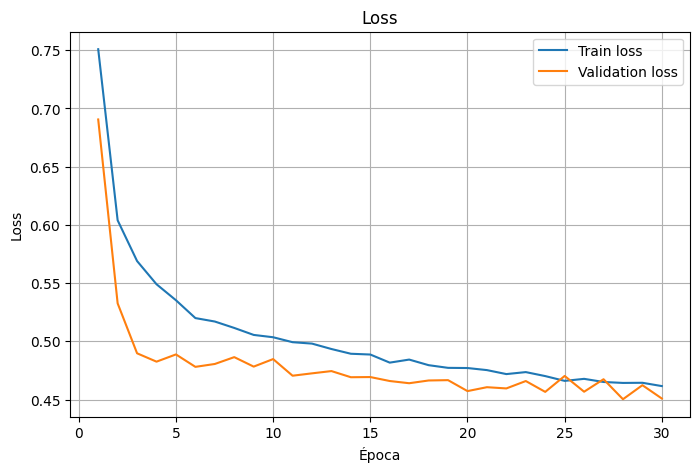

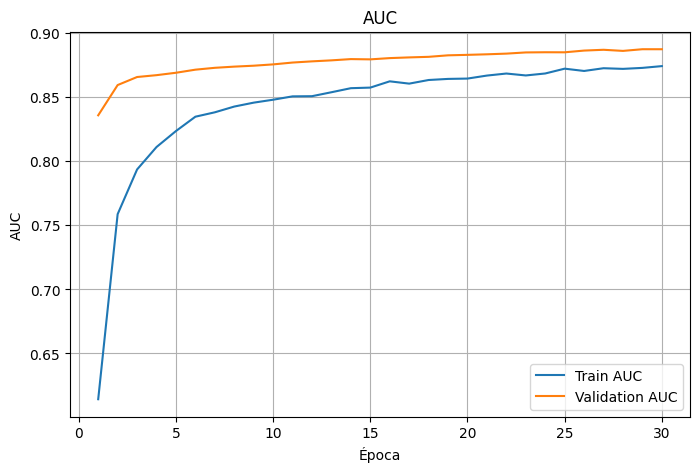

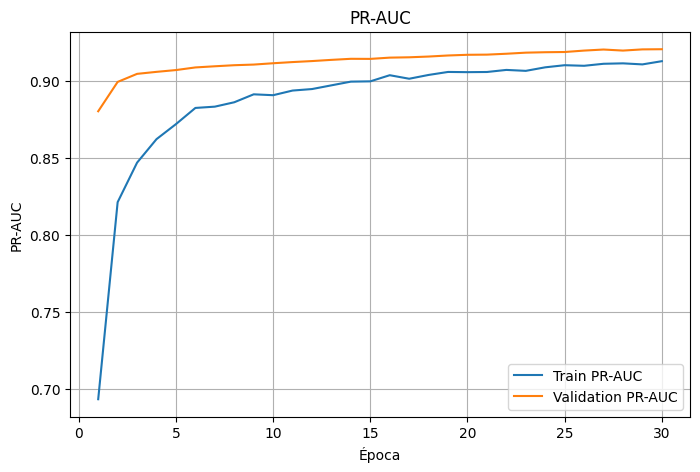

MEJOR ÉPOCA
Época: 30
Train PR-AUC: 0.9127
Val PR-AUC:   0.9205


In [21]:
# ============================================================
# CELDA 24
# Graficar curvas de entrenamiento
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Mostramos loss, AUC y PR-AUC para observar aprendizaje y posible sobreajuste.
# ------------------------------------------------------------

historia = historial.history
epocas = range(1, len(historia["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epocas, historia["loss"], label="Train loss")
plt.plot(epocas, historia["val_loss"], label="Validation loss")
plt.title("Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epocas, historia["auc"], label="Train AUC")
plt.plot(epocas, historia["val_auc"], label="Validation AUC")
plt.title("AUC")
plt.xlabel("Época")
plt.ylabel("AUC")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epocas, historia["pr_auc"], label="Train PR-AUC")
plt.plot(epocas, historia["val_pr_auc"], label="Validation PR-AUC")
plt.title("PR-AUC")
plt.xlabel("Época")
plt.ylabel("PR-AUC")
plt.legend()
plt.grid()
plt.show()

mejor_epoca = int(np.argmax(historia["val_pr_auc"])) + 1

print("=" * 70)
print("MEJOR ÉPOCA")
print("=" * 70)
print(f"Época: {mejor_epoca}")
print(f"Train PR-AUC: {historia['pr_auc'][mejor_epoca - 1]:.4f}")
print(f"Val PR-AUC:   {historia['val_pr_auc'][mejor_epoca - 1]:.4f}")


In [22]:
# ============================================================
# CELDA 25
# Cargar el mejor modelo
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Usamos el archivo guardado por ModelCheckpoint. La capa personalizada está registrada, por lo que Keras puede reconstruirla.
# ------------------------------------------------------------

mejor_modelo = keras.models.load_model(
    RUTA_MEJOR_MODELO,
    compile=False,
)

mejor_modelo.summary()

print("✓ MEJOR MODELO CARGADO")
print(f"Parámetros: {mejor_modelo.count_params():,}")


Model: "Agent1_TinyECGNet_Sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aumento_ecg (AumentoECG)        │ (None, 2500, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv (Conv1D)              │ (None, 1250, 12)       │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)    │ (None, 1250, 12)       │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu (ReLU)                │ (None, 1250, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque1_sepconv                 │ (None, 1250, 16)       │           372 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque1_bn (BatchNormalization) │ (None, 1250, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque1_relu (ReLU)             │ (None, 1250, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 625, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_espacial1               │ (None, 625, 16)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque2_sepconv                 │ (None, 625, 24)        │           624 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque2_bn (BatchNormalization) │ (None, 625, 24)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque2_relu (ReLU)             │ (None, 625, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 312, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_espacial2               │ (None, 312, 24)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque3_sepconv                 │ (None, 312, 32)        │         1,128 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque3_bn (BatchNormalization) │ (None, 312, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque3_relu (ReLU)             │ (None, 312, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 156, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ promedio_global                 │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_final (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,673 (10.44 KB)

 Trainable params: 2,505 (9.79 KB)

 Non-trainable params: 168 (672.00 B)

✓ MEJOR MODELO CARGADO
Parámetros: 2,673


In [23]:
# ============================================================
# CELDA 26
# Evaluación Keras sobre TEST
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Generamos las probabilidades sobre TEST y calculamos Accuracy, Precision, Sensibilidad, Especificidad, FPR, FNR, F1, ROC-AUC y PR-AUC usando threshold=0.50.
# ------------------------------------------------------------

probabilidades_keras = mejor_modelo.predict(
    señales_test,
    batch_size=TAMANO_LOTE,
    verbose=1,
).reshape(-1)

predicciones_keras = (
    probabilidades_keras >= UMBRAL
).astype(np.uint8)

matriz_confusion_keras = confusion_matrix(
    etiquetas_test,
    predicciones_keras,
    labels=[0, 1],
)

tn_keras = matriz_confusion_keras[0, 0]
fp_keras = matriz_confusion_keras[0, 1]
fn_keras = matriz_confusion_keras[1, 0]
tp_keras = matriz_confusion_keras[1, 1]

exactitud_keras = accuracy_score(
    etiquetas_test,
    predicciones_keras,
)

precision_keras = precision_score(
    etiquetas_test,
    predicciones_keras,
    zero_division=0,
)

sensibilidad_keras = recall_score(
    etiquetas_test,
    predicciones_keras,
    zero_division=0,
)

especificidad_keras = (
    tn_keras / (tn_keras + fp_keras)
    if (tn_keras + fp_keras) > 0
    else 0.0
)

fpr_keras = (
    fp_keras / (fp_keras + tn_keras)
    if (fp_keras + tn_keras) > 0
    else 0.0
)

fnr_keras = (
    fn_keras / (fn_keras + tp_keras)
    if (fn_keras + tp_keras) > 0
    else 0.0
)

f1_keras = f1_score(
    etiquetas_test,
    predicciones_keras,
    zero_division=0,
)

roc_auc_keras = roc_auc_score(
    etiquetas_test,
    probabilidades_keras,
)

pr_auc_keras = average_precision_score(
    etiquetas_test,
    probabilidades_keras,
)

print("=" * 70)
print("MÉTRICAS KERAS — TEST")
print("=" * 70)
print(f"Threshold:     {UMBRAL:.2f}")
print(f"Accuracy:      {exactitud_keras:.4f}")
print(f"Precision:     {precision_keras:.4f}")
print(f"Sensibilidad:  {sensibilidad_keras:.4f}")
print(f"Especificidad: {especificidad_keras:.4f}")
print(f"FPR:           {fpr_keras:.4f}")
print(f"FNR:           {fnr_keras:.4f}")
print(f"F1:            {f1_keras:.4f}")
print(f"ROC-AUC:       {roc_auc_keras:.6f}")
print(f"PR-AUC:        {pr_auc_keras:.6f}")
print(f"TN={tn_keras}, FP={fp_keras}, FN={fn_keras}, TP={tp_keras}")


34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step
MÉTRICAS KERAS — TEST
Threshold:     0.50
Accuracy:      0.7894
Precision:     0.8853
Sensibilidad:  0.7243
Especificidad: 0.8757
FPR:           0.1243
FNR:           0.2757
F1:            0.7967
ROC-AUC:       0.882407
PR-AUC:        0.918584
TN=796, FP=113, FN=332, TP=872


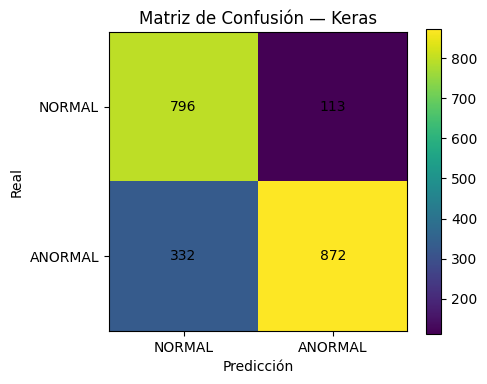

In [24]:
# ============================================================
# CELDA 27
# Matriz de confusión Keras
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Visualizamos los cuatro resultados posibles del clasificador.
# ------------------------------------------------------------

plt.figure(figsize=(5, 4))
plt.imshow(matriz_confusion_keras, interpolation="nearest")
plt.title("Matriz de Confusión — Keras")
plt.colorbar()

plt.xticks([0, 1], ["NORMAL", "ANORMAL"])
plt.yticks([0, 1], ["NORMAL", "ANORMAL"])
plt.xlabel("Predicción")
plt.ylabel("Real")

for fila in range(2):
    for columna in range(2):
        plt.text(
            columna,
            fila,
            matriz_confusion_keras[fila, columna],
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()


In [25]:
# ============================================================
# CELDA 28
# Guardar evaluación Keras
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Guardamos las probabilidades, predicciones, etiquetas y métricas para reproducir el análisis sin volver a ejecutar la red.
# ------------------------------------------------------------

RUTA_RESULTADOS_TEST = os.path.join(
    CARPETA_RESULTADOS,
    "resultados_test_keras_sequential.npz",
)

np.savez(
    RUTA_RESULTADOS_TEST,
    y_true=etiquetas_test,
    y_prob=probabilidades_keras,
    y_pred=predicciones_keras,
    threshold=UMBRAL,
    TN=tn_keras,
    FP=fp_keras,
    FN=fn_keras,
    TP=tp_keras,
    accuracy=exactitud_keras,
    precision=precision_keras,
    sensibilidad=sensibilidad_keras,
    especificidad=especificidad_keras,
    fpr=fpr_keras,
    fnr=fnr_keras,
    f1=f1_keras,
    roc_auc=roc_auc_keras,
    pr_auc=pr_auc_keras,
)

print(f"✓ RESULTADOS GUARDADOS EN:\n{RUTA_RESULTADOS_TEST}")


✓ RESULTADOS GUARDADOS EN:
/content/drive/MyDrive/entrenamiento/results_sequential/resultados_test_keras_sequential.npz


In [26]:
# ============================================================
# CELDA 29
# Preparar modelo limpio para inferencia
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Quitamos únicamente la capa de augmentación para crear un modelo de despliegue. El resto de la arquitectura y los pesos son iguales.
# ------------------------------------------------------------

modelo_inferencia = keras.Sequential(
    [
        keras.Input(
            shape=(LONGITUD_ECG, 1),
            name="entrada_ecg",
        ),

        layers.Conv1D(
            12, 15, strides=2, padding="same",
            use_bias=False,
            kernel_regularizer=regularizers.l2(REGULARIZACION_L2),
            name="stem_conv",
        ),
        layers.BatchNormalization(name="stem_bn"),
        layers.ReLU(name="stem_relu"),

        layers.SeparableConv1D(
            16, 15, padding="same",
            use_bias=False,
            depthwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            pointwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            name="bloque1_sepconv",
        ),
        layers.BatchNormalization(name="bloque1_bn"),
        layers.ReLU(name="bloque1_relu"),
        layers.MaxPooling1D(2, name="pool1"),
        layers.SpatialDropout1D(0.10, name="dropout_espacial1"),

        layers.SeparableConv1D(
            24, 15, padding="same",
            use_bias=False,
            depthwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            pointwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            name="bloque2_sepconv",
        ),
        layers.BatchNormalization(name="bloque2_bn"),
        layers.ReLU(name="bloque2_relu"),
        layers.MaxPooling1D(2, name="pool2"),
        layers.SpatialDropout1D(0.15, name="dropout_espacial2"),

        layers.SeparableConv1D(
            32, 15, padding="same",
            use_bias=False,
            depthwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            pointwise_regularizer=regularizers.l2(REGULARIZACION_L2),
            name="bloque3_sepconv",
        ),
        layers.BatchNormalization(name="bloque3_bn"),
        layers.ReLU(name="bloque3_relu"),
        layers.MaxPooling1D(2, name="pool3"),

        layers.GlobalAveragePooling1D(name="promedio_global"),
        layers.Dropout(0.50, name="dropout_final"),
        layers.Dense(1, activation="sigmoid", name="salida"),
    ],
    name="Agent1_TinyECGNet_Inferencia",
)

# Copiar pesos por nombre.
capas_entrenamiento = {
    capa.name: capa
    for capa in mejor_modelo.layers
}

for capa_destino in modelo_inferencia.layers:
    if capa_destino.name in capas_entrenamiento:
        pesos = capas_entrenamiento[capa_destino.name].get_weights()
        if pesos:
            capa_destino.set_weights(pesos)

print(f"Parámetros: {modelo_inferencia.count_params():,}")


Parámetros: 2,673


In [27]:
# ============================================================
# CELDA 30
# Verificar equivalencia Keras vs modelo de inferencia
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# El modelo entrenado contiene augmentación, pero en inferencia esa capa es identidad. Por eso ambos modelos deben producir prácticamente la misma salida.
# ------------------------------------------------------------

probabilidades_inferencia = modelo_inferencia.predict(
    señales_test,
    batch_size=TAMANO_LOTE,
    verbose=1,
).reshape(-1)

diferencias = np.abs(
    probabilidades_keras - probabilidades_inferencia
)

predicciones_inferencia = (
    probabilidades_inferencia >= UMBRAL
).astype(np.uint8)

cantidad_diferentes = np.sum(
    predicciones_keras != predicciones_inferencia
)

print("=" * 70)
print("EQUIVALENCIA")
print("=" * 70)
print(f"Diferencia máxima: {np.max(diferencias):.12f}")
print(f"Diferencia media:  {np.mean(diferencias):.12f}")
print(f"Predicciones diferentes: {cantidad_diferentes}")

assert np.max(diferencias) < 1e-5
assert cantidad_diferentes == 0

print("✓ MODELOS EQUIVALENTES PARA INFERENCIA")


34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
EQUIVALENCIA
Diferencia máxima: 0.000000000000
Diferencia media:  0.000000000000
Predicciones diferentes: 0
✓ MODELOS EQUIVALENTES PARA INFERENCIA


In [28]:
# ============================================================
# CELDA 31
# Convertir a TFLite FP32
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Convertimos el modelo limpio de inferencia a TensorFlow Lite sin cuantización.
# ------------------------------------------------------------

RUTA_TFLITE_FP32 = os.path.join(
    CARPETA_TFLITE,
    "agent1_tinyecgnet_sequential_fp32.tflite",
)

convertidor = tf.lite.TFLiteConverter.from_keras_model(
    modelo_inferencia
)

convertidor.optimizations = []

modelo_tflite_fp32 = convertidor.convert()

with open(RUTA_TFLITE_FP32, "wb") as archivo:
    archivo.write(modelo_tflite_fp32)

print(f"✓ TFLITE FP32 GENERADO")
print(f"Ruta: {RUTA_TFLITE_FP32}")
print(f"Tamaño: {os.path.getsize(RUTA_TFLITE_FP32) / 1024:.2f} KB")


Saved artifact at '/tmp/tmp_us5qqbz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2500, 1), dtype=tf.float32, name='entrada_ecg')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134789184637072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184640144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184649168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184648592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134788756595984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184645712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184645904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789355978384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789355977040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789355978000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789355978192: Te

In [29]:
# ============================================================
# CELDA 32
# Verificar TFLite FP32
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Ejecutamos TFLite FP32 sobre TEST y comprobamos que la conversión no cambie las clases.
# ------------------------------------------------------------

interprete_fp32 = tf.lite.Interpreter(
    model_path=RUTA_TFLITE_FP32,
)

interprete_fp32.allocate_tensors()

entrada_fp32 = interprete_fp32.get_input_details()[0]
salida_fp32 = interprete_fp32.get_output_details()[0]

probabilidades_tflite_fp32 = np.zeros(
    len(señales_test),
    dtype=np.float32,
)

for indice in range(len(señales_test)):
    muestra = señales_test[indice:indice + 1].astype(np.float32)

    interprete_fp32.set_tensor(
        entrada_fp32["index"],
        muestra,
    )

    interprete_fp32.invoke()

    salida = interprete_fp32.get_tensor(
        salida_fp32["index"],
    )

    probabilidades_tflite_fp32[indice] = (
        salida.reshape(-1)[0]
    )

predicciones_tflite_fp32 = (
    probabilidades_tflite_fp32 >= UMBRAL
).astype(np.uint8)

diferencia_fp32 = np.abs(
    probabilidades_inferencia - probabilidades_tflite_fp32
)

cantidad_diferentes_fp32 = np.sum(
    predicciones_inferencia != predicciones_tflite_fp32
)

print("=" * 70)
print("KERAS vs TFLITE FP32")
print("=" * 70)
print(f"Diferencia máxima: {np.max(diferencia_fp32):.12f}")
print(f"Diferencia media:  {np.mean(diferencia_fp32):.12f}")
print(f"RMSE: {np.sqrt(np.mean(diferencia_fp32 ** 2)):.12f}")
print(f"Predicciones diferentes: {cantidad_diferentes_fp32}")
print(f"Porcentaje diferente: {100 * cantidad_diferentes_fp32 / len(señales_test):.4f}%")

print("✓ COMPARACIÓN FP32 COMPLETADA")


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


KERAS vs TFLITE FP32
Diferencia máxima: 0.000000178814
Diferencia media:  0.000000030158
RMSE: 0.000000042032
Predicciones diferentes: 0
Porcentaje diferente: 0.0000%
✓ COMPARACIÓN FP32 COMPLETADA


In [30]:
# ============================================================
# CELDA 33
# Preparar dataset representativo para INT8
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Usamos hasta 500 ECG de TRAIN para calibrar la cuantización. Nunca usamos TEST para calibración.
# ------------------------------------------------------------

cantidad_representativa = min(
    500,
    len(señales_train),
)

generador_aleatorio = np.random.default_rng(SEMILLA)

indices_representativos = generador_aleatorio.choice(
    len(señales_train),
    size=cantidad_representativa,
    replace=False,
)

señales_representativas = señales_train[
    indices_representativos
].astype(np.float32)

print("=" * 70)
print("DATASET REPRESENTATIVO")
print("=" * 70)
print(f"ECG utilizados: {cantidad_representativa}")
print(f"Shape: {señales_representativas.shape}")


DATASET REPRESENTATIVO
ECG utilizados: 500
Shape: (500, 2500, 1)


In [31]:
# ============================================================
# CELDA 34
# Función de calibración INT8
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# El conversor recibe un ECG representativo a la vez. No se filtra ni normaliza aquí porque los datos ya fueron preprocesados.
# ------------------------------------------------------------

def dataset_representativo():
    for ecg in señales_representativas:
        yield [
            ecg[np.newaxis, ...].astype(np.float32)
        ]

print("✓ DATASET REPRESENTATIVO LISTO")


✓ DATASET REPRESENTATIVO LISTO


In [32]:
# ============================================================
# CELDA 35
# Convertir a TFLite INT8
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Forzamos cuantización completa: entrada, pesos, activaciones y salida en INT8.
# ------------------------------------------------------------

RUTA_TFLITE_INT8 = os.path.join(
    CARPETA_TFLITE,
    "agent1_tinyecgnet_sequential_int8.tflite",
)

convertidor_int8 = tf.lite.TFLiteConverter.from_keras_model(
    modelo_inferencia
)

convertidor_int8.optimizations = [
    tf.lite.Optimize.DEFAULT
]

convertidor_int8.representative_dataset = (
    dataset_representativo
)

convertidor_int8.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

convertidor_int8.inference_input_type = tf.int8
convertidor_int8.inference_output_type = tf.int8

modelo_tflite_int8 = convertidor_int8.convert()

with open(RUTA_TFLITE_INT8, "wb") as archivo:
    archivo.write(modelo_tflite_int8)

print("✓ TFLITE INT8 GENERADO")
print(f"Ruta: {RUTA_TFLITE_INT8}")
print(f"Tamaño: {os.path.getsize(RUTA_TFLITE_INT8) / 1024:.2f} KB")


Saved artifact at '/tmp/tmpu066uls3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2500, 1), dtype=tf.float32, name='entrada_ecg')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134789184637072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184640144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184649168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184648592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134788756595984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184645712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789184645904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789355978384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789355977040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789355978000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134789355978192: Te

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✓ TFLITE INT8 GENERADO
Ruta: /content/drive/MyDrive/entrenamiento/models_sequential/tflite/agent1_tinyecgnet_sequential_int8.tflite
Tamaño: 18.15 KB


In [33]:
# ============================================================
# CELDA 36
# Obtener parámetros de cuantización
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Leemos directamente del modelo INT8 la escala y zero-point de entrada y salida. Estos valores serán necesarios en el ESP32.
# ------------------------------------------------------------

interprete_int8 = tf.lite.Interpreter(
    model_path=RUTA_TFLITE_INT8,
)

interprete_int8.allocate_tensors()

entrada_int8 = interprete_int8.get_input_details()[0]
salida_int8 = interprete_int8.get_output_details()[0]

escala_entrada, zero_point_entrada = (
    entrada_int8["quantization"]
)

escala_salida, zero_point_salida = (
    salida_int8["quantization"]
)

print("=" * 70)
print("MODELO INT8")
print("=" * 70)

print("INPUT")
print(f"Shape: {entrada_int8['shape']}")
print(f"Dtype: {entrada_int8['dtype']}")
print(f"Scale: {escala_entrada}")
print(f"Zero point: {zero_point_entrada}")

print("\nOUTPUT")
print(f"Shape: {salida_int8['shape']}")
print(f"Dtype: {salida_int8['dtype']}")
print(f"Scale: {escala_salida}")
print(f"Zero point: {zero_point_salida}")

assert entrada_int8["dtype"] == np.int8
assert salida_int8["dtype"] == np.int8

print("\n✓ MODELO FULL INTEGER INT8 CONFIRMADO")


MODELO INT8
INPUT
Shape: [   1 2500    1]
Dtype: <class 'numpy.int8'>
Scale: 0.0817062109708786
Zero point: -18

OUTPUT
Shape: [1 1]
Dtype: <class 'numpy.int8'>
Scale: 0.00390625
Zero point: -128

✓ MODELO FULL INTEGER INT8 CONFIRMADO


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [34]:
# ============================================================
# CELDA 37
# Funciones de cuantización
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# TFLite usa la relación real = (int8 - zero_point) × scale. Estas funciones implementan la conversión de entrada y salida.
# ------------------------------------------------------------

def cuantizar_entrada(señal):
    señal_cuantizada = (
        np.round(
            señal / escala_entrada
        )
        + zero_point_entrada
    )

    señal_cuantizada = np.clip(
        señal_cuantizada,
        -128,
        127,
    )

    return señal_cuantizada.astype(np.int8)


def descuantizar_salida(salida):
    return (
        salida.astype(np.float32)
        - zero_point_salida
    ) * escala_salida

print("✓ FUNCIONES DE CUANTIZACIÓN PREPARADAS")


✓ FUNCIONES DE CUANTIZACIÓN PREPARADAS


In [35]:
# ============================================================
# CELDA 38
# Evaluar TFLite INT8 sobre TEST
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Ejecutamos el modelo INT8 sobre todos los ECG de TEST, cuantizando exactamente la entrada que recibiría el ESP32.
# ------------------------------------------------------------

probabilidades_int8 = np.zeros(
    len(señales_test),
    dtype=np.float32,
)

for indice in range(len(señales_test)):
    muestra = señales_test[
        indice:indice + 1
    ].astype(np.float32)

    muestra_int8 = cuantizar_entrada(muestra)

    interprete_int8.set_tensor(
        entrada_int8["index"],
        muestra_int8,
    )

    interprete_int8.invoke()

    salida = interprete_int8.get_tensor(
        salida_int8["index"],
    )

    probabilidades_int8[indice] = (
        descuantizar_salida(salida)
        .reshape(-1)[0]
    )

predicciones_int8 = (
    probabilidades_int8 >= UMBRAL
).astype(np.uint8)

print("=" * 70)
print("INFERENCIA INT8 COMPLETADA")
print("=" * 70)
print(f"ECG evaluados: {len(probabilidades_int8)}")
print(f"Probabilidad mínima: {np.min(probabilidades_int8):.6f}")
print(f"Probabilidad máxima: {np.max(probabilidades_int8):.6f}")
print(f"Media: {np.mean(probabilidades_int8):.6f}")


INFERENCIA INT8 COMPLETADA
ECG evaluados: 2113
Probabilidad mínima: 0.089844
Probabilidad máxima: 0.996094
Media: 0.518189


In [36]:
# ============================================================
# CELDA 39
# Comparar FP32 vs INT8
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Medimos cuánto cambia la probabilidad y cuántas clases cambian después de la cuantización.
# ------------------------------------------------------------

diferencia_int8 = np.abs(
    probabilidades_inferencia - probabilidades_int8
)

cantidad_diferentes_int8 = np.sum(
    predicciones_inferencia != predicciones_int8
)

rmse_int8 = np.sqrt(
    np.mean(diferencia_int8 ** 2)
)

print("=" * 70)
print("TFLITE FP32 vs TFLITE INT8")
print("=" * 70)
print(f"Diferencia máxima: {np.max(diferencia_int8):.12f}")
print(f"Diferencia media:  {np.mean(diferencia_int8):.12f}")
print(f"RMSE:              {rmse_int8:.12f}")
print(f"Predicciones diferentes: {cantidad_diferentes_int8}")
print(
    f"Porcentaje diferente: "
    f"{100 * cantidad_diferentes_int8 / len(señales_test):.4f}%"
)

if cantidad_diferentes_int8 == 0:
    print("\n✓ INT8 CONSERVA TODAS LAS CLASES")
else:
    print("\n⚠ INT8 CAMBIA ALGUNAS CLASES")


TFLITE FP32 vs TFLITE INT8
Diferencia máxima: 0.036830544472
Diferencia media:  0.007383578457
RMSE:              0.009949058294
Predicciones diferentes: 22
Porcentaje diferente: 1.0412%

⚠ INT8 CAMBIA ALGUNAS CLASES


In [37]:
# ============================================================
# CELDA 40
# Métricas finales INT8
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Calculamos las mismas métricas clínicas de clasificación usando el modelo INT8.
# ------------------------------------------------------------

matriz_confusion_int8 = confusion_matrix(
    etiquetas_test,
    predicciones_int8,
    labels=[0, 1],
)

tn_int8 = matriz_confusion_int8[0, 0]
fp_int8 = matriz_confusion_int8[0, 1]
fn_int8 = matriz_confusion_int8[1, 0]
tp_int8 = matriz_confusion_int8[1, 1]

exactitud_int8 = accuracy_score(
    etiquetas_test,
    predicciones_int8,
)

precision_int8 = precision_score(
    etiquetas_test,
    predicciones_int8,
    zero_division=0,
)

sensibilidad_int8 = recall_score(
    etiquetas_test,
    predicciones_int8,
    zero_division=0,
)

especificidad_int8 = (
    tn_int8 / (tn_int8 + fp_int8)
    if (tn_int8 + fp_int8) > 0
    else 0.0
)

f1_int8 = f1_score(
    etiquetas_test,
    predicciones_int8,
    zero_division=0,
)

roc_auc_int8 = roc_auc_score(
    etiquetas_test,
    probabilidades_int8,
)

pr_auc_int8 = average_precision_score(
    etiquetas_test,
    probabilidades_int8,
)

print("=" * 70)
print("MÉTRICAS TFLITE INT8 — TEST")
print("=" * 70)
print(f"Threshold:     {UMBRAL:.2f}")
print(f"Accuracy:      {exactitud_int8:.4f}")
print(f"Precision:     {precision_int8:.4f}")
print(f"Sensibilidad:  {sensibilidad_int8:.4f}")
print(f"Especificidad: {especificidad_int8:.4f}")
print(f"F1:            {f1_int8:.4f}")
print(f"ROC-AUC:       {roc_auc_int8:.6f}")
print(f"PR-AUC:        {pr_auc_int8:.6f}")
print(f"TN={tn_int8}, FP={fp_int8}, FN={fn_int8}, TP={tp_int8}")


MÉTRICAS TFLITE INT8 — TEST
Threshold:     0.50
Accuracy:      0.7960
Precision:     0.8838
Sensibilidad:  0.7392
Especificidad: 0.8713
F1:            0.8051
ROC-AUC:       0.882092
PR-AUC:        0.917556
TN=792, FP=117, FN=314, TP=890


In [38]:
# ============================================================
# CELDA 41
# Comparación Keras, FP32 e INT8
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Esta tabla permite comprobar si las conversiones mantienen el comportamiento del modelo.
# ------------------------------------------------------------

metricas_comparacion = {
    "Keras": (
        exactitud_keras,
        precision_keras,
        sensibilidad_keras,
        especificidad_keras,
        f1_keras,
    ),
    "TFLite FP32": (
        accuracy_score(etiquetas_test, predicciones_tflite_fp32),
        precision_score(etiquetas_test, predicciones_tflite_fp32, zero_division=0),
        recall_score(etiquetas_test, predicciones_tflite_fp32, zero_division=0),
        (
            confusion_matrix(etiquetas_test, predicciones_tflite_fp32, labels=[0, 1])[0, 0]
            /
            (
                confusion_matrix(etiquetas_test, predicciones_tflite_fp32, labels=[0, 1])[0, 0]
                + confusion_matrix(etiquetas_test, predicciones_tflite_fp32, labels=[0, 1])[0, 1]
            )
        ),
        f1_score(etiquetas_test, predicciones_tflite_fp32, zero_division=0),
    ),
    "TFLite INT8": (
        exactitud_int8,
        precision_int8,
        sensibilidad_int8,
        especificidad_int8,
        f1_int8,
    ),
}

print("=" * 70)
print("COMPARACIÓN FINAL")
print("=" * 70)

print(
    f"{'Modelo':<18}"
    f"{'Accuracy':>12}"
    f"{'Precision':>12}"
    f"{'Sensibilidad':>14}"
    f"{'Especificidad':>15}"
    f"{'F1':>10}"
)

print("-" * 83)

for nombre, valores in metricas_comparacion.items():
    print(
        f"{nombre:<18}"
        f"{valores[0]:>12.4f}"
        f"{valores[1]:>12.4f}"
        f"{valores[2]:>14.4f}"
        f"{valores[3]:>15.4f}"
        f"{valores[4]:>10.4f}"
    )

print(f"\nThreshold: {UMBRAL:.2f}")


COMPARACIÓN FINAL
Modelo                Accuracy   Precision  Sensibilidad  Especificidad        F1
-----------------------------------------------------------------------------------
Keras                   0.7894      0.8853        0.7243         0.8757    0.7967
TFLite FP32             0.7894      0.8853        0.7243         0.8757    0.7967
TFLite INT8             0.7960      0.8838        0.7392         0.8713    0.8051

Threshold: 0.50


In [39]:
# ============================================================
# CELDA 42
# Threshold en dominio INT8
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Convertimos el threshold 0.50 a su representación cuantizada para poder clasificar directamente la salida INT8 en el ESP32.
# ------------------------------------------------------------

threshold_int8 = int(
    np.round(
        UMBRAL / escala_salida
        + zero_point_salida
    )
)

threshold_int8 = int(
    np.clip(
        threshold_int8,
        -128,
        127,
    )
)

threshold_reconstruido = (
    threshold_int8 - zero_point_salida
) * escala_salida

print("=" * 70)
print("THRESHOLD PARA ESP32")
print("=" * 70)
print(f"Threshold real:          {UMBRAL:.6f}")
print(f"Threshold INT8:          {threshold_int8}")
print(f"Threshold reconstruido:  {threshold_reconstruido:.6f}")


THRESHOLD PARA ESP32
Threshold real:          0.500000
Threshold INT8:          0
Threshold reconstruido:  0.500000


In [40]:
# ============================================================
# CELDA 43
# Inspección del modelo INT8
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Mostramos entrada, salida, tensores y operadores para conocer exactamente qué deberá soportar TFLite Micro.
# ------------------------------------------------------------

todos_los_tensores = interprete_int8.get_tensor_details()
operadores = interprete_int8._get_ops_details()

print("=" * 70)
print("INSPECCIÓN TFLITE INT8")
print("=" * 70)

print(f"Cantidad de tensores: {len(todos_los_tensores)}")
print(f"Cantidad de operadores: {len(operadores)}")

print("\nOPERADORES:")
operadores_unicos = []

for operador in operadores:
    nombre = operador["op_name"]
    if nombre not in operadores_unicos:
        operadores_unicos.append(nombre)

for numero, nombre in enumerate(operadores_unicos, start=1):
    print(f"{numero:02d}. {nombre}")

print("\n✓ INSPECCIÓN COMPLETADA")


INSPECCIÓN TFLITE INT8
Cantidad de tensores: 53
Cantidad de operadores: 34

OPERADORES:
01. EXPAND_DIMS
02. CONV_2D
03. RESHAPE
04. DEPTHWISE_CONV_2D
05. MAX_POOL_2D
06. MEAN
07. FULLY_CONNECTED
08. LOGISTIC
09. DELEGATE

✓ INSPECCIÓN COMPLETADA


In [41]:
# ============================================================
# CELDA 44
# Estimar memoria de tensores
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Esta estimación no sustituye Tensor Arena de TFLite Micro, pero sirve para conocer el orden de magnitud.
# ------------------------------------------------------------

def calcular_bytes_tensor(detalle_tensor):
    forma = np.asarray(
        detalle_tensor["shape"],
        dtype=np.int64,
    )

    cantidad_elementos = int(np.prod(forma))
    tamaño_dtype = np.dtype(
        detalle_tensor["dtype"]
    ).itemsize

    return cantidad_elementos * tamaño_dtype


memoria_total_tensores = sum(
    calcular_bytes_tensor(tensor)
    for tensor in todos_los_tensores
)

print("=" * 70)
print("ESTIMACIÓN DE MEMORIA")
print("=" * 70)
print(f"Memoria de tensores: {memoria_total_tensores:,} bytes")
print(f"En KB: {memoria_total_tensores / 1024:.2f} KB")
print("\nNOTA: el Tensor Arena real debe medirse en TFLite Micro.")


ESTIMACIÓN DE MEMORIA
Memoria de tensores: 282,898 bytes
En KB: 276.27 KB

NOTA: el Tensor Arena real debe medirse en TFLite Micro.


In [42]:
# ============================================================
# CELDA 45
# Generar header C para ESP32
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Convertimos el archivo TFLite INT8 en un arreglo de bytes C/C++ para incluirlo directamente en el firmware del esp32.
# ------------------------------------------------------------

RUTA_MODELO_H = os.path.join(
    CARPETA_MODELOS,
    "agent1_tinyecgnet_sequential_int8_model.h",
)

with open(RUTA_TFLITE_INT8, "rb") as archivo:
    datos_modelo = archivo.read()

tamaño_modelo = len(datos_modelo)

with open(RUTA_MODELO_H, "w") as archivo:
    archivo.write(
        "#ifndef AGENT1_TINYECGNET_SEQUENTIAL_INT8_MODEL_H\n"
    )
    archivo.write(
        "#define AGENT1_TINYECGNET_SEQUENTIAL_INT8_MODEL_H\n\n"
    )
    archivo.write("#include <stdint.h>\n\n")
    archivo.write(
        "alignas(16) const unsigned char "
        "agent1_tinyecgnet_sequential_int8_model[] = {\n"
    )

    for inicio in range(0, tamaño_modelo, 12):
        bloque = datos_modelo[inicio:inicio + 12]

        linea = ", ".join(
            f"0x{byte:02X}"
            for byte in bloque
        )

        archivo.write(f"    {linea},\n")

    archivo.write("};\n\n")
    archivo.write(
        "const unsigned int "
        "agent1_tinyecgnet_sequential_int8_model_len = "
        f"{tamaño_modelo};\n\n"
    )
    archivo.write("#endif\n")

print("=" * 70)
print("HEADER C GENERADO")
print("=" * 70)
print(f"Archivo: {RUTA_MODELO_H}")
print(f"Tamaño del modelo: {tamaño_modelo:,} bytes")


HEADER C GENERADO
Archivo: /content/drive/MyDrive/entrenamiento/models_sequential/agent1_tinyecgnet_sequential_int8_model.h
Tamaño del modelo: 18,584 bytes


In [43]:
# ============================================================
# CELDA 46
# Verificar integridad del header C
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Leemos nuevamente los bytes hexadecimales del `.h` y comprobamos que sean idénticos al `.tflite` original.
# ------------------------------------------------------------

with open(RUTA_MODELO_H, "r") as archivo:
    contenido_header = archivo.read()

valores_hexadecimales = re.findall(
    r"0x([0-9A-Fa-f]{2})",
    contenido_header,
)

bytes_header = bytes(
    int(valor, 16)
    for valor in valores_hexadecimales
)

with open(RUTA_TFLITE_INT8, "rb") as archivo:
    bytes_tflite = archivo.read()

print("=" * 70)
print("INTEGRIDAD TFLITE ↔ HEADER C")
print("=" * 70)
print(f"TFLite: {len(bytes_tflite):,} bytes")
print(f"Header: {len(bytes_header):,} bytes")
print(f"Contenido idéntico: {bytes_tflite == bytes_header}")

assert bytes_tflite == bytes_header

print("\n✓ HEADER C IDÉNTICO AL TFLITE")


INTEGRIDAD TFLITE ↔ HEADER C
TFLite: 18,584 bytes
Header: 18,584 bytes
Contenido idéntico: True

✓ HEADER C IDÉNTICO AL TFLITE


In [44]:

# ============================================================
# CELDA 47
# Guardar configuración para ESP32
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Guardamos frecuencia, longitud, threshold y parámetros de
# cuantización para no tener que copiarlos manualmente.
#
# El archivo generado será un header C/C++ que puede incluirse
# directamente en el firmware del ESP32.
# ------------------------------------------------------------

RUTA_CONFIG_ESP32 = os.path.join(
    CARPETA_MODELOS,
    "agent1_ecg_sequential_config.h",
)


# ------------------------------------------------------------
# Generar configuración C/C++
# ------------------------------------------------------------

texto_configuracion = f"""#ifndef AGENT1_ECG_SEQUENTIAL_CONFIG_H
#define AGENT1_ECG_SEQUENTIAL_CONFIG_H

#include <stdint.h>

// ============================================================
// CONFIGURACIÓN DE LA SEÑAL ECG
// ============================================================

#define ECG_FRECUENCIA_MUESTREO_HZ {FRECUENCIA_MUESTREO}
#define ECG_DURACION_SEGUNDOS {DURACION_SEGUNDOS}
#define ECG_LONGITUD_MUESTRA {LONGITUD_ECG}

// Nombre de la derivación utilizada
#define ECG_DERIVACION "{NOMBRE_DERIVACION}"


// ============================================================
// THRESHOLD DEL MODELO
// ============================================================

// Threshold original en dominio float
#define ECG_THRESHOLD_FLOAT {UMBRAL:.8f}

// Threshold cuantizado para salida INT8
#define ECG_THRESHOLD_INT8 {threshold_int8}


// ============================================================
// CUANTIZACIÓN DE LA SALIDA DEL MODELO
// ============================================================

// scale de la salida INT8
#define ECG_OUTPUT_SCALE {escala_salida:.12f}

// zero point de la salida INT8
#define ECG_OUTPUT_ZERO_POINT {zero_point_salida}


// ============================================================
// THRESHOLD RECONSTRUIDO
// ============================================================

// Valor real obtenido al reconstruir ECG_THRESHOLD_INT8
#define ECG_THRESHOLD_RECONSTRUIDO {threshold_reconstruido:.8f}


// ============================================================
// INFORMACIÓN DEL MODELO
// ============================================================

#define ECG_MODELO_CUANTIZADO_INT8 1


#endif  // AGENT1_ECG_SEQUENTIAL_CONFIG_H
"""


# ------------------------------------------------------------
# Guardar archivo
# ------------------------------------------------------------

with open(
    RUTA_CONFIG_ESP32,
    "w",
    encoding="utf-8",
) as archivo:

    archivo.write(texto_configuracion)


# ------------------------------------------------------------
# Mostrar resultado
# ------------------------------------------------------------

print("=" * 70)
print("CONFIGURACIÓN ESP32 GENERADA")
print("=" * 70)

print(f"Archivo:")
print(RUTA_CONFIG_ESP32)

print("\n" + texto_configuracion)

print("✓ CONFIGURACIÓN GENERADA CORRECTAMENTE")



CONFIGURACIÓN ESP32 GENERADA
Archivo:
/content/drive/MyDrive/entrenamiento/models_sequential/agent1_ecg_sequential_config.h

#ifndef AGENT1_ECG_SEQUENTIAL_CONFIG_H
#define AGENT1_ECG_SEQUENTIAL_CONFIG_H

#include <stdint.h>

// ============================================================
// CONFIGURACIÓN DE LA SEÑAL ECG
// ============================================================

#define ECG_FRECUENCIA_MUESTREO_HZ 250
#define ECG_DURACION_SEGUNDOS 10
#define ECG_LONGITUD_MUESTRA 2500

// Nombre de la derivación utilizada
#define ECG_DERIVACION "II"


// ============================================================
// THRESHOLD DEL MODELO
// ============================================================

// Threshold original en dominio float
#define ECG_THRESHOLD_FLOAT 0.50000000

// Threshold cuantizado para salida INT8
#define ECG_THRESHOLD_INT8 0


// ============================================================
// CUANTIZACIÓN DE LA SALIDA DEL MODELO
// ============================

In [45]:
# ============================================================
# CELDA 48
# Resumen final del experimento
# ============================================================

# ------------------------------------------------------------
# EXPLICACIÓN:
# Esta última celda concentra los resultados principales y las rutas de los archivos destinados al ESP32.
# ------------------------------------------------------------

print("=" * 80)
print("RESUMEN FINAL — AGENT1 TinyECGNet Sequential")
print("=" * 80)

print("\nDATOS")
print(f"Frecuencia:       {FRECUENCIA_MUESTREO} Hz")
print(f"Ventana:          {DURACION_SEGUNDOS} s")
print(f"Muestras:         {LONGITUD_ECG}")
print(f"Derivación:       {NOMBRE_DERIVACION}")

print("\nKERAS")
print(f"Accuracy:         {exactitud_keras:.4f}")
print(f"Precision:        {precision_keras:.4f}")
print(f"Sensibilidad:     {sensibilidad_keras:.4f}")
print(f"Especificidad:    {especificidad_keras:.4f}")
print(f"F1:               {f1_keras:.4f}")
print(f"ROC-AUC:          {roc_auc_keras:.6f}")
print(f"PR-AUC:           {pr_auc_keras:.6f}")

print("\nINT8")
print(f"Accuracy:         {exactitud_int8:.4f}")
print(f"Precision:        {precision_int8:.4f}")
print(f"Sensibilidad:     {sensibilidad_int8:.4f}")
print(f"Especificidad:    {especificidad_int8:.4f}")
print(f"F1:               {f1_int8:.4f}")
print(f"Threshold INT8:   {threshold_int8}")

print("\nARCHIVOS")
print(f"Mejor Keras:      {RUTA_MEJOR_MODELO}")
print(f"TFLite FP32:      {RUTA_TFLITE_FP32}")
print(f"TFLite INT8:      {RUTA_TFLITE_INT8}")
print(f"Header C:         {RUTA_MODELO_H}")
print(f"Config ESP32:     {RUTA_CONFIG_ESP32}")

print("\n✓ NOTEBOOK COMPLETADO")


RESUMEN FINAL — AGENT1 TinyECGNet Sequential

DATOS
Frecuencia:       250 Hz
Ventana:          10 s
Muestras:         2500
Derivación:       II

KERAS
Accuracy:         0.7894
Precision:        0.8853
Sensibilidad:     0.7243
Especificidad:    0.8757
F1:               0.7967
ROC-AUC:          0.882407
PR-AUC:           0.918584

INT8
Accuracy:         0.7960
Precision:        0.8838
Sensibilidad:     0.7392
Especificidad:    0.8713
F1:               0.8051
Threshold INT8:   0

ARCHIVOS
Mejor Keras:      /content/drive/MyDrive/entrenamiento/models_sequential/mejor_tiny_ecgnet_sequential.keras
TFLite FP32:      /content/drive/MyDrive/entrenamiento/models_sequential/tflite/agent1_tinyecgnet_sequential_fp32.tflite
TFLite INT8:      /content/drive/MyDrive/entrenamiento/models_sequential/tflite/agent1_tinyecgnet_sequential_int8.tflite
Header C:         /content/drive/MyDrive/entrenamiento/models_sequential/agent1_tinyecgnet_sequential_int8_model.h
Config ESP32:     /content/drive/MyDrive/ent